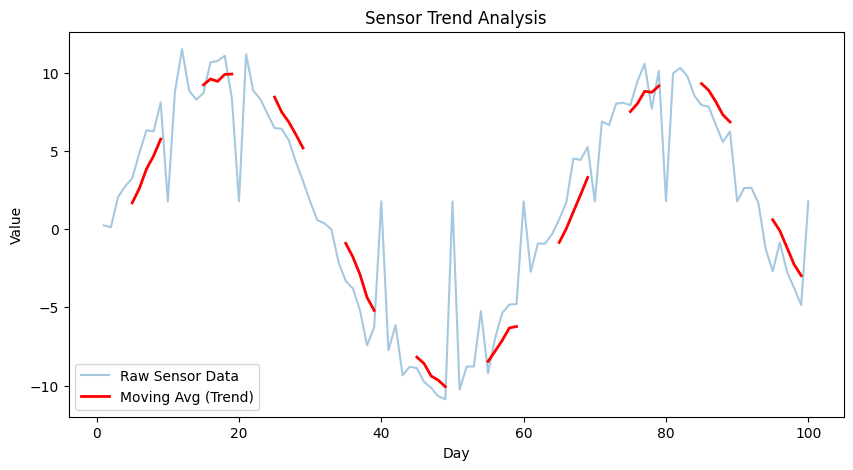

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

size = 100
data = {
    "day": np.arange(1, size + 1),
    "value": np.sin(np.linspace(0, 10, size)) * 10 + np.random.normal(0, 1, size)
}
df = pl.DataFrame(data)

df = df.with_columns(
    pl.when(pl.col("day") % 10 == 0).then(None).otherwise(pl.col("value")).alias("value")
)

df = df.with_columns([
    pl.col("value").fill_null(pl.col("value").mean()),
    pl.col("value").rolling_mean(window_size=5).alias("moving_avg")
])

plt.figure(figsize=(10, 5))
plt.plot(df["day"], df["value"], label="Raw Sensor Data", alpha=0.4)
plt.plot(df["day"], df["moving_avg"], label="Moving Avg (Trend)", color="red", linewidth=2)
plt.title("Sensor Trend Analysis")
plt.xlabel("Day")
plt.ylabel("Value")
plt.legend()
plt.show()

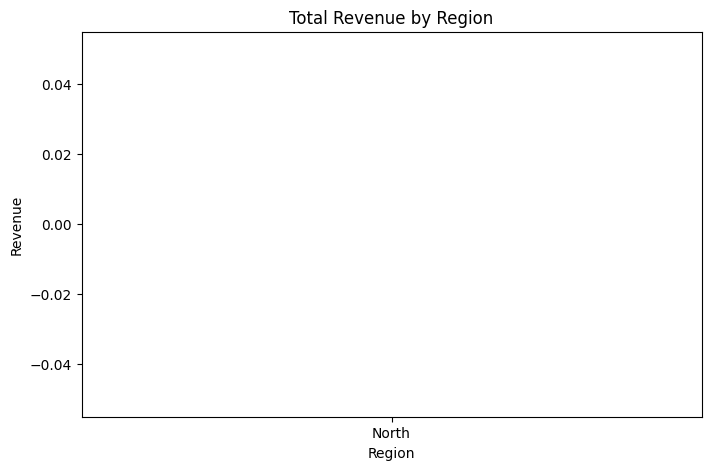

shape: (4, 2)
┌────────┬───────────────┐
│ Region ┆ Total_Revenue │
│ ---    ┆ ---           │
│ str    ┆ f64           │
╞════════╪═══════════════╡
│ North  ┆ NaN           │
│ East   ┆ NaN           │
│ South  ┆ NaN           │
│ West   ┆ NaN           │
└────────┴───────────────┘


In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

n_rows = 500
data = {
    "Region": np.random.choice(["North", "South", "East", "West"], n_rows),
    "Product": np.random.choice(["Laptop", "Phone", "Tablet"], n_rows),
    "Units": np.random.randint(1, 10, n_rows),
    "Price": np.random.randint(500, 2000, n_rows).astype(float)
}

data["Price"][np.random.choice(n_rows, 10)] = None

df = pl.DataFrame(data)

df = df.with_columns([
    pl.col("Price").fill_null(df["Price"].median()),
    (pl.col("Units") * pl.col("Price")).alias("Revenue")
])

summary = df.group_by("Region").agg(
    pl.col("Revenue").sum().alias("Total_Revenue")
).sort("Total_Revenue", descending=True)

plt.figure(figsize=(8, 5))
plt.bar(summary["Region"], summary["Total_Revenue"], color='skyblue')
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

print(summary)